In [1]:
import os
import sys
import math
import time
from pathlib import Path
import importlib
import importlib.util
import types

import cv2
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# Bootstrap: 현재 작업 위치 기준으로 RGMC 프로젝트 루트 찾기
# =========================================================
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (
            (p / "src").exists()
            and (p / "configs").exists()
            and (p / "data").exists()
            and (p / "notebooks").exists()
        ):
            return p
    raise RuntimeError(
        f"RGMC PROJECT_ROOT를 찾지 못했습니다. start={start}, "
        "expected markers: src/, configs/, data/, notebooks/."
    )


CWD = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CWD)

SRC_ROOT = PROJECT_ROOT / "src"
CONFIG_ROOT = PROJECT_ROOT / "configs"
DATA_ROOT = PROJECT_ROOT / "data"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks"

TASK1_DIR = SRC_ROOT / "task1"
PERCEPTION_DIR = TASK1_DIR / "perception"
CALIBRATION_DIR = SRC_ROOT / "calibration"
COMMON_CAMERA_DIR = SRC_ROOT / "common" / "camera"
CLOUDGRIPPER_CLIENT_DIR = SRC_ROOT / "cloudgripper_api" / "client"
EVALUATION_DIR = SRC_ROOT / "evaluation"


# =========================================================
# sys.path 정리
#
# 중요:
# - task1 package import를 위해 SRC_ROOT 필요
# - brain.py 내부 bare import(motion_planner, total_, perf_utils, config 등)를 위해
#   TASK1_DIR도 필요
# - detector / mapper / camera / client / evaluator 쪽 bare import를 위해 각 디렉토리 추가
# =========================================================
desired_paths = [
    str(TASK1_DIR),               # bare import: motion_planner, total_, perf_utils, config
    str(SRC_ROOT),                # package import: task1.xxx
    str(PERCEPTION_DIR),          # merged_T_det_refactored
    str(CALIBRATION_DIR),         # pixel_to_workspace
    str(COMMON_CAMERA_DIR),       # calib_fisheye_cam
    str(CLOUDGRIPPER_CLIENT_DIR), # cloudgripper_client
    str(EVALUATION_DIR),          # shapes / evaluator helper
]

for p in reversed(desired_paths):
    if p in sys.path:
        sys.path.remove(p)
    sys.path.insert(0, p)

print("CWD                :", CWD)
print("PROJECT_ROOT       :", PROJECT_ROOT)
print("SRC_ROOT           :", SRC_ROOT, SRC_ROOT.exists())
print("TASK1_DIR          :", TASK1_DIR, TASK1_DIR.exists())
print("PERCEPTION_DIR     :", PERCEPTION_DIR, PERCEPTION_DIR.exists())
print("CALIBRATION_DIR    :", CALIBRATION_DIR, CALIBRATION_DIR.exists())
print("COMMON_CAMERA_DIR  :", COMMON_CAMERA_DIR, COMMON_CAMERA_DIR.exists())
print("CLOUDGRIPPER_DIR   :", CLOUDGRIPPER_CLIENT_DIR, CLOUDGRIPPER_CLIENT_DIR.exists())
print("EVALUATION_DIR     :", EVALUATION_DIR, EVALUATION_DIR.exists())
print("CONFIG_ROOT        :", CONFIG_ROOT)
print("DATA_ROOT          :", DATA_ROOT)


# =========================================================
# .env 로드
# =========================================================
try:
    from dotenv import load_dotenv
    ENV_PATH = PROJECT_ROOT / ".env"
    load_dotenv(ENV_PATH)
    print("dotenv loaded from:", ENV_PATH)
except Exception as e:
    print("dotenv not used:", repr(e))


# =========================================================
# geometry_utils 별칭 주입
# - 현재 task1 코드 일부가 geometry_utils 이름을 기대하므로
#   push_geometry.py를 geometry_utils로 alias
# =========================================================
push_geometry_path = TASK1_DIR / "push_geometry.py"
if "geometry_utils" in sys.modules:
    del sys.modules["geometry_utils"]

spec = importlib.util.spec_from_file_location("geometry_utils", str(push_geometry_path))
geometry_utils = importlib.util.module_from_spec(spec)
sys.modules["geometry_utils"] = geometry_utils
assert spec.loader is not None
spec.loader.exec_module(geometry_utils)
print("geometry_utils alias ->", push_geometry_path)


# =========================================================
# config 충돌 방지
# - 이전 실행에서 calibration/config.py 가 config로 잡혔을 수 있으므로 제거
# - task1/config.py 를 명시적으로 'config' 이름으로 먼저 주입
#   -> brain.py 내부의 'from task1 import config' / 'import config' 류를 안정화
# =========================================================
for mod_name in [
    "config",
    "task1.config",
    "task1.brain",
    "task1.planner",
    "task1.robot_executor",
    "task1.motion_planner",
    "task1.total_",
    "task1.perf_utils",
]:
    if mod_name in sys.modules:
        del sys.modules[mod_name]

task1_config_path = TASK1_DIR / "config.py"
config_spec = importlib.util.spec_from_file_location("config", str(task1_config_path))
task1_config = importlib.util.module_from_spec(config_spec)
sys.modules["config"] = task1_config
assert config_spec.loader is not None
config_spec.loader.exec_module(task1_config)

print("config alias ->", task1_config.__file__)
print("config has PERF_LOG_SIM_EVERY:", hasattr(task1_config, "PERF_LOG_SIM_EVERY"))


# =========================================================
# Imports
# =========================================================
from cloudgripper_client import GripperRobot
# 필요 시:
# from cloudgripper_client_mock import GripperRobotMock

from task1.brain import PushingBrain
from task1.planner import Planner
from task1.robot_executor import CloudGripperExecutor
from task1.push_geometry import get_global_corners, make_circle_polygon

import merged_T_det_refactored as detector

from pixel_to_workspace import PixelToWorkspaceMapper
from calib_fisheye_cam import (
    undistort_image,
    load_parameters_from_file,
)
from shapes import SQUARE_CORNERS, CIRCLE_CORNERS, T_CORNERS

print("all core imports success")


# =========================================================
# RGMC evaluator import 시도
# - src/evaluation/pushing_task_iou_calculator.py가 상대 import를 기대할 수 있어서
#   evaluation 패키지를 임시로 구성
# =========================================================
PushingTaskIOU_Calculator = None
EVALUATOR_IMPORT_ERROR = None

try:
    if "evaluation" not in sys.modules:
        evaluation_pkg = types.ModuleType("evaluation")
        evaluation_pkg.__path__ = [str(EVALUATION_DIR)]
        sys.modules["evaluation"] = evaluation_pkg

    import calib_fisheye_cam as _camera_mod
    import shapes as _shapes_mod
    sys.modules["evaluation.calib_fisheye_cam"] = _camera_mod
    sys.modules["evaluation.shapes"] = _shapes_mod

    eval_spec = importlib.util.spec_from_file_location(
        "evaluation.pushing_task_iou_calculator",
        str(EVALUATION_DIR / "pushing_task_iou_calculator.py"),
    )
    eval_mod = importlib.util.module_from_spec(eval_spec)
    sys.modules["evaluation.pushing_task_iou_calculator"] = eval_mod
    assert eval_spec.loader is not None
    eval_spec.loader.exec_module(eval_mod)
    PushingTaskIOU_Calculator = eval_mod.PushingTaskIOU_Calculator
    print("evaluator import: success")

except Exception as e:
    EVALUATOR_IMPORT_ERROR = e
    print("evaluator import failed:", repr(e))


# =========================================================
# User settings
# =========================================================
ROBOT_ID = 29
ROBOT_NAME = f"robot{ROBOT_ID}"

CLOUDGRIPPER_TOKEN = os.getenv("CLOUDGRIPPER_TOKEN")
if not CLOUDGRIPPER_TOKEN:
    raise RuntimeError(
        "CLOUDGRIPPER_TOKEN not set. "
        "프로젝트 루트의 .env 또는 현재 셸 환경변수에 설정하세요."
    )

USE_LIVE_ROBOT = True
EXECUTE_PUSH = True
USE_RGMC_EVAL = PushingTaskIOU_Calculator is not None

# 실제 usable workspace 크기(mm)
USABLE_WORKSPACE_X_MM = 150.0
USABLE_WORKSPACE_Y_MM = 150.0

# pixel -> workspace LUT
ROBOT_MAP_DIR = DATA_ROOT / "map" / ROBOT_NAME
LUT_PATH = ROBOT_MAP_DIR / "lut.pkl"

# robot별 camera params
PARAM_FILE = CONFIG_ROOT / "camera" / f"camera-params-cr{ROBOT_ID:02d}.yaml"

# target pose in workspace-normalized coordinates
TARGET_POSE = [0.5, 0.5, 0.0]

# pixel->workspace usable bounds
X_MIN, X_MAX = 0.0, 0.95
Y_MIN, Y_MAX = 0.0, 1.0

print("ROBOT_NAME        :", ROBOT_NAME)
print("PARAM_FILE        :", PARAM_FILE, PARAM_FILE.exists())
print("LUT_PATH          :", LUT_PATH, LUT_PATH.exists())
print("TARGET_POSE       :", TARGET_POSE)
print(
    "Task1 workspace size:",
    task1_config.REAL_WORKSPACE_SIZE_X,
    task1_config.REAL_WORKSPACE_SIZE_Y,
)

if EVALUATOR_IMPORT_ERROR is not None:
    print("Evaluator disabled because import failed:", repr(EVALUATOR_IMPORT_ERROR))

if not PARAM_FILE.exists():
    raise FileNotFoundError(f"Camera parameter file not found: {PARAM_FILE}")
if not LUT_PATH.exists():
    raise FileNotFoundError(f"LUT file not found: {LUT_PATH}")


# =========================================================
# Robot connection
# =========================================================
if USE_LIVE_ROBOT:
    robot = GripperRobot(ROBOT_NAME, token=CLOUDGRIPPER_TOKEN)
else:
    raise RuntimeError("Mock robot path/config not set in this notebook.")

state_out = robot.get_state()
if isinstance(state_out, tuple):
    state, ts = state_out
else:
    state, ts = state_out, None

print("robot state:", state)
print("timestamp  :", ts)


# =========================================================
# Helper functions
# =========================================================
def decode_bgr_image(img_base):
    if isinstance(img_base, np.ndarray):
        return img_base.copy()
    img_array = np.frombuffer(img_base, dtype=np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError("Failed to decode img_base into BGR image.")
    return img


def load_camera_params_from_yaml(param_file):
    K, D = load_parameters_from_file(str(param_file))
    return np.asarray(K, dtype=np.float64), np.asarray(D, dtype=np.float64).reshape(-1, 1)


def undistort_only_image(img_bgr, K, D):
    return undistort_image(K, D, img_bgr)


def preprocess_base_image_undistort_only(img_base, param_file=PARAM_FILE):
    img_bgr = decode_bgr_image(img_base)
    K, D = load_camera_params_from_yaml(param_file)
    processed_img = undistort_only_image(img_bgr, K, D)
    return processed_img, K, D, str(param_file)


def show_bgr(img, title="image", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


def pretty_print(obj, title=None):
    if title:
        print(f"\n[{title}]")
    import pprint
    pprint.pprint(obj)


def select_task_object(task_inputs):
    if not task_inputs:
        return None
    return task_inputs[0]


def get_local_corners_and_radius(shape_type):
    local_corners = task1_config.get_shape_corners(shape_type)
    radius = task1_config.get_shape_radius(shape_type)
    return local_corners, radius


def build_world_polygon(shape_type, pose, local_corners, radius):
    if shape_type == "WEIGHTED_CIRCLE":
        return make_circle_polygon(pose[:2], radius, task1_config.CIRCLE_POLY_POINTS)
    return get_global_corners(pose, local_corners)


def compute_internal_iou(task_object, target_pose):
    planner = Planner(task1_config)
    shape_type = task_object["shape_type"]
    current_pose = task_object["current_pose"]

    local_corners, radius = get_local_corners_and_radius(shape_type)

    cur_poly = build_world_polygon(shape_type, current_pose, local_corners, radius)
    tgt_poly = build_world_polygon(shape_type, target_pose, local_corners, radius)

    iou = planner.calculate_iou(
        planner.world_to_mask(cur_poly),
        planner.world_to_mask(tgt_poly),
        planner.mask_shape,
    )
    return float(iou), cur_poly, tgt_poly


def workspace_pose_to_rgmc_mm(target_pose, usable_x_mm=150.0, usable_y_mm=150.0):
    x_norm, y_norm, theta = target_pose
    offset_x_mm = (float(x_norm) - 0.5) * float(usable_x_mm)
    offset_y_mm = (0.5 - float(y_norm)) * float(usable_y_mm)
    return [offset_x_mm, offset_y_mm], float(theta)


def get_eval_shape_corners_mm(shape_type):
    if shape_type == "WEIGHTED_SQUARE":
        return SQUARE_CORNERS
    if shape_type == "WEIGHTED_CIRCLE":
        return CIRCLE_CORNERS
    if shape_type == "T_BASE":
        return T_CORNERS
    raise ValueError(f"Unsupported shape_type: {shape_type}")


def summarize_plan(plan):
    if plan is None:
        print("plan: None")
        return
    cand = plan["candidate"]
    motion = plan["motion"]
    print("score:", plan["score"])
    print("progress:", plan["progress"])
    print("align:", plan["align"])
    print("current_shape_err:", plan["current_shape_err"])
    print("next_shape_err:", plan["next_shape_err"])
    print("start:", cand["start"])
    print("end:", cand["end"])
    print("n_hat:", cand["n_hat"])
    print("t_hat:", cand["t_hat"])
    print("approach_path_len:", len(motion["approach_path"]))
    print("approach_xy:", motion["approach_xy"])
    print("retreat_xy:", motion["retreat_xy"])


# =========================================================
# Mapper / planner / brain / executor / evaluator init
# =========================================================
mapper = PixelToWorkspaceMapper(
    str(LUT_PATH),
    clamp_to_workspace=False,
    x_min=X_MIN, x_max=X_MAX,
    y_min=Y_MIN, y_max=Y_MAX,
)

planner = Planner(task1_config)
brain = PushingBrain()
executor = CloudGripperExecutor(robot)

evaluator = None
if USE_RGMC_EVAL:
    evaluator = PushingTaskIOU_Calculator(str(PARAM_FILE))

print("mapper, planner, brain, executor ready")
print("evaluator ready:", evaluator is not None)

CWD                : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\notebooks\test
PROJECT_ROOT       : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC
SRC_ROOT           : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\src True
TASK1_DIR          : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\src\task1 True
PERCEPTION_DIR     : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\src\task1\perception True
CALIBRATION_DIR    : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\src\calibration True
COMMON_CAMERA_DIR  : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\src\common\camera True
CLOUDGRIPPER_DIR   : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\src\cloudgripper_api\client True
EVALUATION_DIR     : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\src\evaluation True
CONFIG_ROOT        : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\configs
DATA_ROOT          : C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\data
dotenv loaded from: C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\.env
geometry_utils alias -> C:\Users\PC\Desktop\RGMC_2026\RGMC\RGMC\src\task1\push_geometry.p

In [2]:
import os
import cv2
from client.cloudgripper_client import GripperRobot

token = "DBlhGCRsba1HPDBkhvg6qLMMq44IltNi"

robot = GripperRobot("robot6", token)

state, t = robot.get_state()
print(state)


{'x_norm': 0.9130714285714285, 'y_norm': 0.8992857142857144, 'z_norm': 0.09999999999999998, 'rotation': 0, 'claw_norm': 0.0, 'z_current': '-0.01', 'rotation_current': '0.01', 'claw_current': '0.02'}


(-0.5, 639.5, 479.5, -0.5)

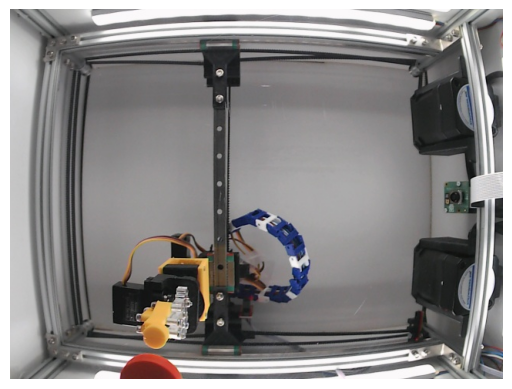

In [3]:
import cv2
import matplotlib.pyplot as plt

img, _ = robot.getImageBase()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")

In [5]:
robot.env_reset()

{'status': 'success', 'message': 'Environment reset successfully.'}

In [13]:
# ===== 0. import =====
import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml
import sys

sys.path.append("../rgmc_cloud_robotics_2026/src")
from rgmc_cloud_robotics_2026.calib_fisheye_cam import undistort_image

# ===== 1. 간단한 HSV 기반 detector 정의 =====
class SimpleGripperDetector:
    def __init__(self):
        # 필요하면 여기 튜닝
        self.lower = np.array([10, 120, 120])
        self.upper = np.array([15, 255, 255])

    def predict(self, image):
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, self.lower, self.upper)

        # noise 제거
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            return {"ok": False, "center_uv": None}

        largest = max(contours, key=cv2.contourArea)

        M = cv2.moments(largest)
        if M["m00"] == 0:
            return {"ok": False, "center_uv": None}

        u = M["m10"] / M["m00"]
        v = M["m01"] / M["m00"]

        return {"ok": True, "center_uv": (u, v), "mask": mask}


# ===== 2. camera params =====
camera_yaml_path = "../rgmc_cloud_robotics_2026/config/base-camera-calibration/camera-params-cr01.yaml"

with open(camera_yaml_path, "r") as f:
    camera_params = yaml.safe_load(f)

# ===== 3. 이미지 획득 =====
img_base, _ = robot.getImageBase()

K = np.array(camera_params["K"])
D = np.array(camera_params["D"])

img = undistort_image(K, D, img_base)
img = cv2.flip(img, 0)
img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)

# ===== 4. detector 실행 =====
detector = SimpleGripperDetector()
pred = detector.predict(img)

print(pred)

# ===== 5. 시각화 =====
vis = img.copy()

if pred["ok"]:
    u, v = pred["center_uv"]
    cv2.circle(vis, (int(u), int(v)), 10, (0, 255, 0), -1)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Gripper Detection")
plt.show()

# ===== 6. mask도 확인 =====
if pred.get("mask") is not None:
    plt.figure(figsize=(6,6))
    plt.imshow(pred["mask"], cmap="gray")
    plt.title("Mask")
    plt.axis("off")
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../rgmc_cloud_robotics_2026/config/base-camera-calibration/camera-params-cr01.yaml'

(-0.5, 639.5, 479.5, -0.5)

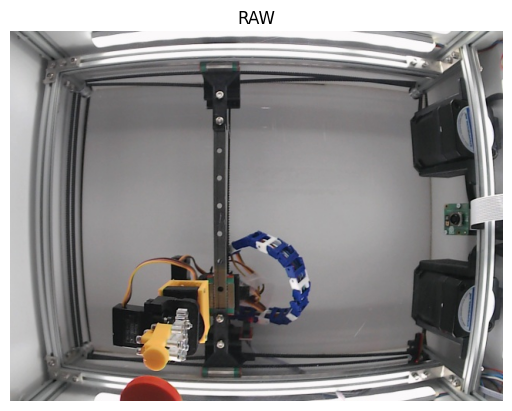

In [9]:
img_raw, _ = robot.getImageBase()

plt.imshow(cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB))
plt.title("RAW")
plt.axis("off")

In [10]:
!python3 autograsper/main.py \
  --mode rope_calibration \
  --config autograsper/my_config_robot1_task2.yaml \
  --three-point-test

/opt/homebrew/Cellar/python@3.11/3.11.12/Frameworks/Python.framework/Versions/3.11/Resources/Python.app/Contents/MacOS/Python: can't open file '/Users/kimsumin/projects/RGMC/cloudgripper-api/autograsper/main.py': [Errno 2] No such file or directory


In [ ]:
import cv2

while True:
    image, timestamp = robot.    ()
    cv2.imshow("Cloudgripper top camera stream", image)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

In [ ]:
mapper = PixelToWorkspaceMapper(str(LUT_PATH), clamp_to_workspace=False,
                                x_min=config.x_min, x_max=config.x_max,
                                y_min=config.y_min, y_max=config.y_max)

sample_uv = [(300.0, 250.0), (320.0, 260.0)]
xy_points = mapper.convert_many(sample_uv)
xy_points


Move to (0.95, 0.05)
Detected center_uv = (469.908, 553.178)


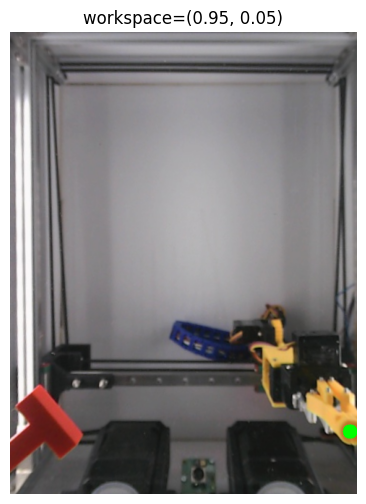


Move to (0.95, 0.95)
Detected center_uv = (469.515, 146.500)


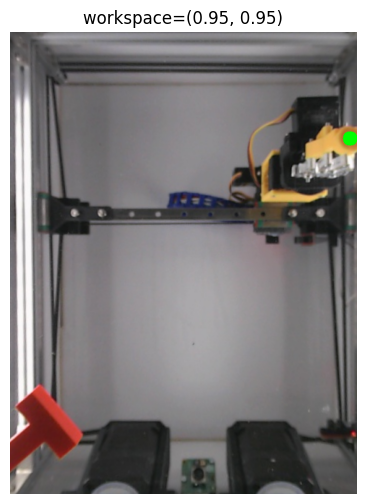


Move to (0.05, 0.95)
Detected center_uv = (66.913, 147.386)


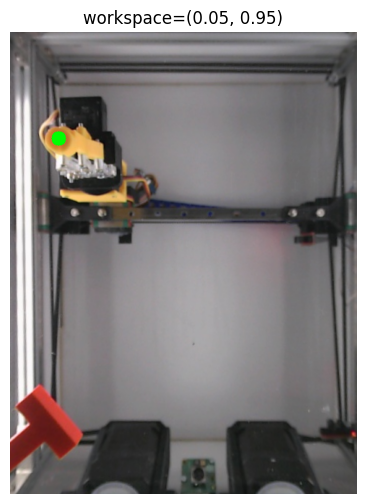


Move to (0.05, 0.05)
Detected center_uv = (69.310, 554.030)


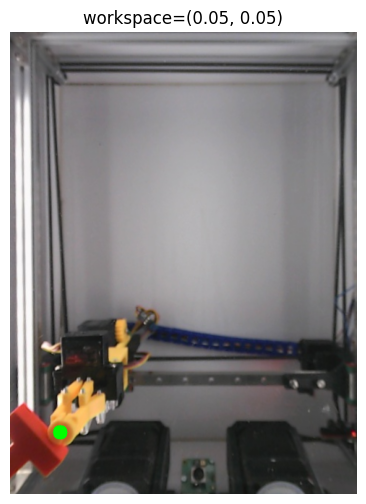


Summary
((0.95, 0.05), (469.9081225033289, 553.1779849090102))
((0.95, 0.95), (469.5151183970856, 146.50018214936247))
((0.05, 0.95), (66.91254866726564, 147.38604372566635))
((0.05, 0.05), (69.31028626880155, 554.0303250849103))


In [10]:
import time
import cv2
import yaml
import numpy as np
import matplotlib.pyplot as plt

# camera params load
with open("../rgmc_cloud_robotics_2026/config/base-camera-calibration/camera-params-cr01.yaml", "r") as f:
    cam = yaml.safe_load(f)

K = np.array(cam["K"], dtype=np.float64)
D = np.array(cam["D"], dtype=np.float64)

class SimpleGripperDetector:
    def __init__(self):
        self.lower = np.array([10, 120, 120], dtype=np.uint8)
        self.upper = np.array([15, 255, 255], dtype=np.uint8)

    def predict(self, image):
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, self.lower, self.upper)

        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return {"ok": False, "center_uv": None, "mask": mask}

        largest = max(contours, key=cv2.contourArea)
        M = cv2.moments(largest)
        if M["m00"] == 0:
            return {"ok": False, "center_uv": None, "mask": mask}

        u = M["m10"] / M["m00"]
        v = M["m01"] / M["m00"]
        return {"ok": True, "center_uv": (u, v), "mask": mask}

detector = SimpleGripperDetector()

def get_processed_base_image(robot):
    img_base, ts = robot.getImageBase()
    img = undistort_image(K, D, img_base)
    img = cv2.flip(img, 0)
    img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    return img, ts

test_points = [
    (0.95, 0.05),
    (0.95, 0.95),
    (0.05, 0.95),
    (0.05, 0.05),
]

results = []

for x, y in test_points:
    print(f"\nMove to ({x:.2f}, {y:.2f})")
    robot.move_xy(x, y)
    time.sleep(1.5)

    img, ts = get_processed_base_image(robot)
    pred = detector.predict(img)

    vis = img.copy()
    if pred["ok"] and pred["center_uv"] is not None:
        u, v = pred["center_uv"]
        cv2.circle(vis, (int(round(u)), int(round(v))), 10, (0, 255, 0), -1)
        print(f"Detected center_uv = ({u:.3f}, {v:.3f})")
        results.append(((x, y), (u, v)))
    else:
        print("Detection failed")
        results.append(((x, y), None))

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"workspace=({x:.2f}, {y:.2f})")
    plt.axis("off")
    plt.show()

print("\nSummary")
for item in results:
    print(item)

In [14]:
import yaml

with open("../autograsper-main/autograsper/my_config_robot1_task2.yaml") as f:
    cfg = yaml.safe_load(f)

print(cfg["rope_calibration"])

{'grid_size': 11, 'x_min': 0.05, 'x_max': 0.95, 'y_min': 0.05, 'y_max': 0.95, 'frames_per_point': 5, 'settle_time_sec': 0.7, 'inter_frame_sec': 0.05, 'reverse_xy': False, 'resume': True, 'save_masks': True, 'write_debug_json': True, 'output_subdir': 'rope_calibration', 'custom_points': None, 'camera_params_file': '../rgmc_cloud_robotics_2026/config/base-camera-calibration/camera-params-cr01.yaml', 'planar_only': True, 'prefer_raw_base_image': True, 'detector_lower_hsv': [10, 120, 120], 'detector_upper_hsv': [15, 255, 255], 'detector_kernel_size': 5, 'detector_min_area': 100}


In [ ]:
import cv2

while True:
    image, timestamp = robot.getImageBase()
    cv2.imshow("Cloudgripper top camera stream", image)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

In [20]:
!python3 ../autograsper-main/autograsper/main.py \
  --mode rope_calibration \
  --config ../autograsper-main/autograsper/my_config_robot1_task2.yaml

2026-03-18 14:54:05,885 INFO: Started new recording in directory: /Users/kimsumin/projects/RGMC/autograsper-main/autograsper/recorded_data/rope_calibration/1/task
 * Serving Flask app 'main'
 * Debug mode: off
Request to getAllStates failed: 403 Client Error: FORBIDDEN for url: https://cloudgripper.eecs.kth.se:8443/robot1/api/v1.1/robot/getAllStates
Request to grip/0.3 failed: 403 Client Error: FORBIDDEN for url: https://cloudgripper.eecs.kth.se:8443/robot1/api/v1.1/robot/grip/0.3
Request to grip/0.3 failed: 403 Client Error: FORBIDDEN for url: https://cloudgripper.eecs.kth.se:8443/robot1/api/v1.1/robot/grip/0.3
Request to grip/0.26 failed: 403 Client Error: FORBIDDEN for url: https://cloudgripper.eecs.kth.se:8443/robot1/api/v1.1/robot/grip/0.26
Request to getAllStates failed: 403 Client Error: FORBIDDEN for url: https://cloudgripper.eecs.kth.se:8443/robot1/api/v1.1/robot/getAllStates
2026-03-18 14:54:09,786 INFO: WARNING: This is a development server. Do not use it in a production dep

In [19]:
import os
os.environ["CLOUDGRIPPER_TOKEN"] = "DBlhGCRsba1HPDBkhvg6qLMMq44IltNi"

Total points: 121
Workspace range: x[0.05, 0.95], y[0.05, 0.95]
CSV path: ./calibration_data_robot1/calibration.csv

[1/121] move to (0.050, 0.050)
  trial 1: detected (41.41, 553.70)


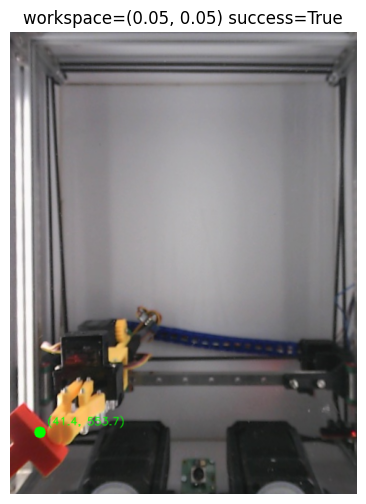


[2/121] move to (0.140, 0.050)
  trial 1: detected (42.19, 553.17)


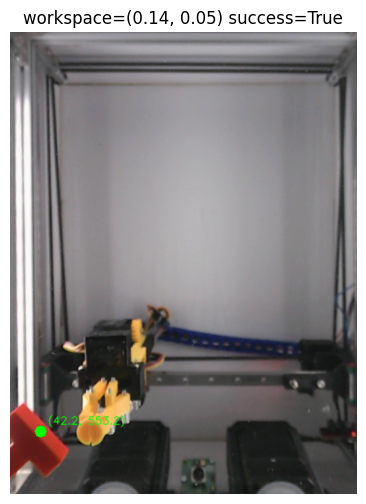


[3/121] move to (0.230, 0.050)
  trial 1: detected (41.86, 552.95)


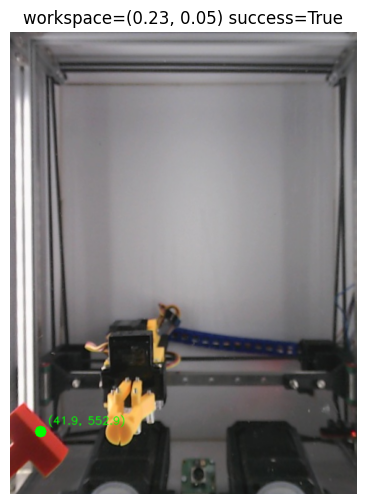


[4/121] move to (0.320, 0.050)
  trial 1: detected (42.24, 553.26)


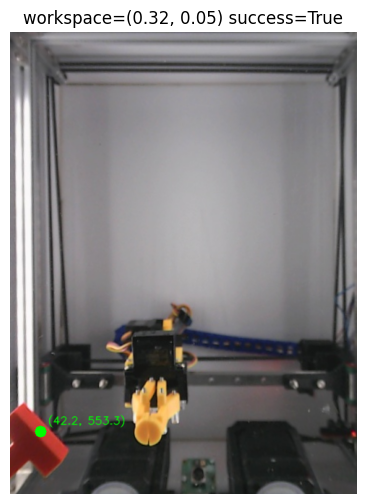


[5/121] move to (0.410, 0.050)
  trial 1: detected (42.42, 553.38)


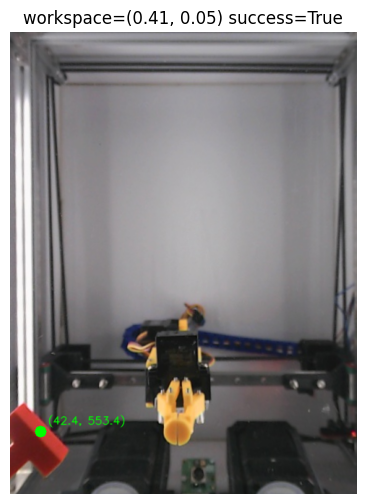


[6/121] move to (0.500, 0.050)
  trial 1: detected (42.12, 553.28)


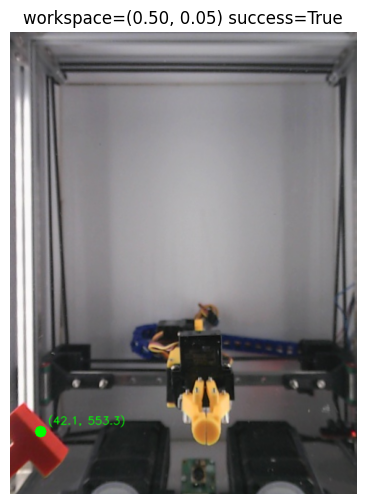


[7/121] move to (0.590, 0.050)
  trial 1: detected (42.46, 553.24)


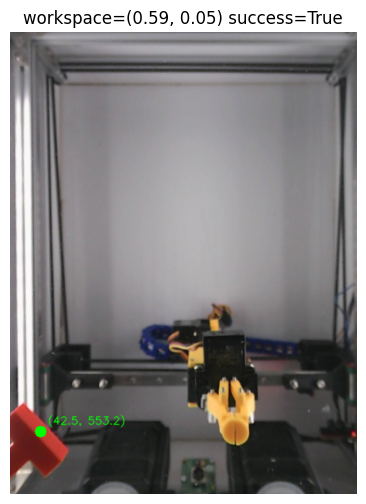


[8/121] move to (0.680, 0.050)
  trial 1: detected (42.53, 553.22)


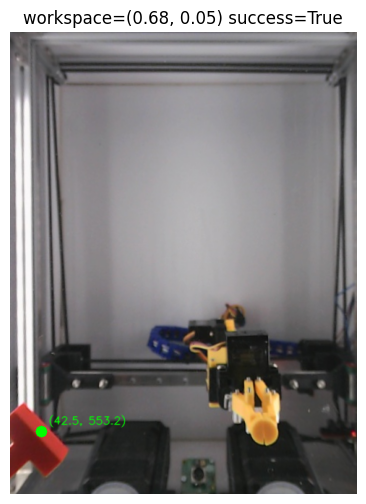


[9/121] move to (0.770, 0.050)
  trial 1: detected (42.38, 553.11)


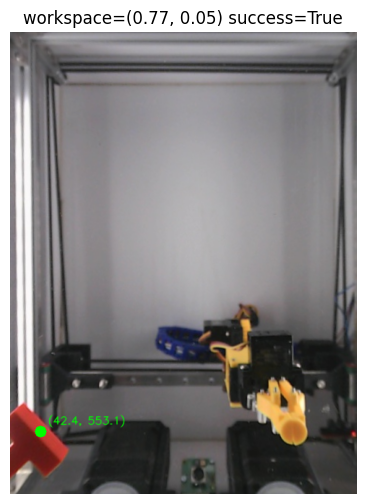


[10/121] move to (0.860, 0.050)
  trial 1: detected (42.45, 553.19)


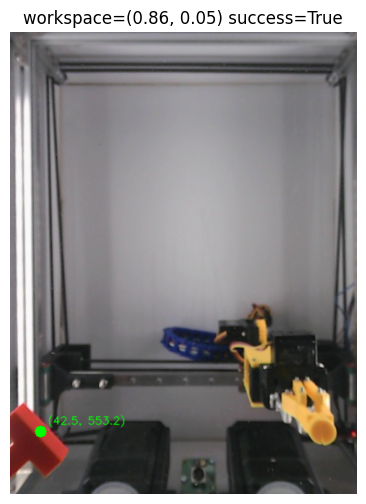


[11/121] move to (0.950, 0.050)
  trial 1: detected (42.37, 553.08)


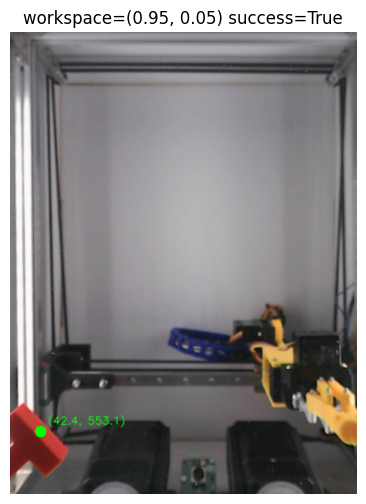


[12/121] move to (0.950, 0.140)
  trial 1: detected (42.45, 553.24)


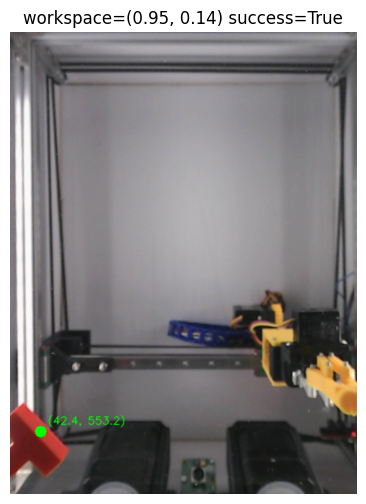


[13/121] move to (0.860, 0.140)
  trial 1: detected (42.39, 553.24)


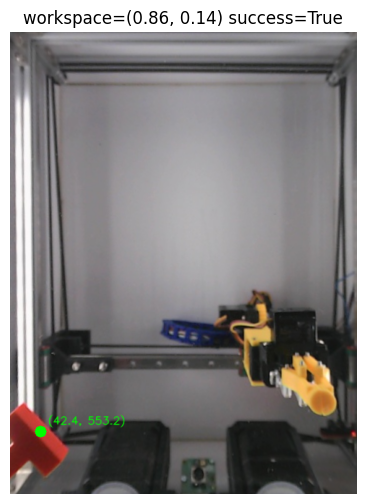


[14/121] move to (0.770, 0.140)
  trial 1: detected (42.28, 553.10)


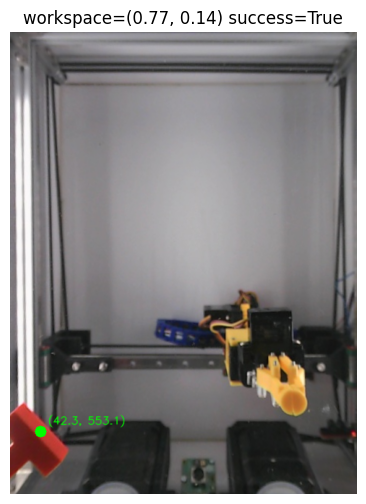


[15/121] move to (0.680, 0.140)
  trial 1: detected (42.13, 553.18)


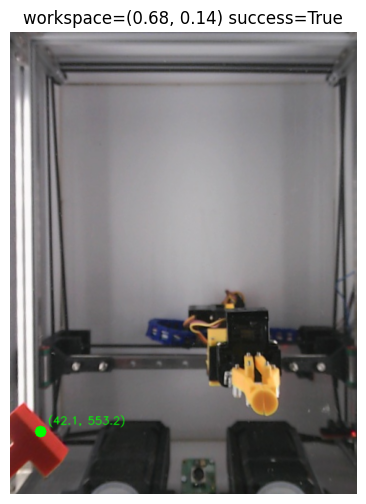


[16/121] move to (0.590, 0.140)


KeyboardInterrupt: 

In [4]:
# =========================
# CloudGripper Task2 calibration collection cell
# =========================

import os
import time
import csv
import yaml
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- RGMC import ----------
import sys
sys.path.append("../rgmc_cloud_robotics_2026/src")
from rgmc_cloud_robotics_2026.calib_fisheye_cam import undistort_image

# ---------- camera params ----------
CAMERA_YAML = "../rgmc_cloud_robotics_2026/config/base-camera-calibration/camera-params-cr01.yaml"

with open(CAMERA_YAML, "r") as f:
    cam = yaml.safe_load(f)

K = np.array(cam["K"], dtype=np.float64)
D = np.array(cam["D"], dtype=np.float64)

# ---------- user config ----------
SAVE_DIR = "./calibration_data_robot1"
os.makedirs(SAVE_DIR, exist_ok=True)

CSV_PATH = os.path.join(SAVE_DIR, "calibration.csv")

X_MIN, X_MAX = 0.05, 0.95
Y_MIN, Y_MAX = 0.05, 0.95
GRID_SIZE = 11
SETTLE_TIME = 1.0
RETRY = 3
SHOW_EVERY = 1   # every N points, show image
SAVE_DEBUG_IMAGES = True

# ---------- detector ----------
# 지금은 HSV 기반 간단 detector.
# 네가 만든 detector가 있으면 이 함수만 바꾸면 됨.
def detect_gripper_center(img_bgr):
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # red mask (two hue ranges)
    lower1 = np.array([0, 120, 120], dtype=np.uint8)
    upper1 = np.array([10, 255, 255], dtype=np.uint8)
    lower2 = np.array([170, 120, 120], dtype=np.uint8)
    upper2 = np.array([180, 255, 255], dtype=np.uint8)

    mask1 = cv2.inRange(hsv, lower1, upper1)
    mask2 = cv2.inRange(hsv, lower2, upper2)
    mask = mask1 + mask2

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, mask

    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < 30:
        return None, mask

    M = cv2.moments(largest)
    if M["m00"] == 0:
        return None, mask

    u = float(M["m10"] / M["m00"])
    v = float(M["m01"] / M["m00"])
    return (u, v), mask

# ---------- image preprocess ----------
def get_processed_base_image(robot):
    img_raw, ts = robot.getImageBase()
    if img_raw is None:
        return None, ts
    img = undistort_image(K, D, img_raw)
    img = cv2.flip(img, 0)
    img = cv2.rotate(img, cv2.ROTATE_90_CLOCKWISE)
    return img, ts

# ---------- grid ----------
xs = np.linspace(X_MIN, X_MAX, GRID_SIZE)
ys = np.linspace(Y_MIN, Y_MAX, GRID_SIZE)

# serpentine order: 이동량 줄이기
grid = []
for j, y in enumerate(ys):
    row_xs = xs if j % 2 == 0 else xs[::-1]
    for x in row_xs:
        grid.append((float(x), float(y)))

print(f"Total points: {len(grid)}")
print(f"Workspace range: x[{X_MIN}, {X_MAX}], y[{Y_MIN}, {Y_MAX}]")
print(f"CSV path: {CSV_PATH}")

# ---------- CSV init ----------
with open(CSV_PATH, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["x", "y", "u", "v", "ok"])

# ---------- main loop ----------
results = []

for idx, (x, y) in enumerate(grid, start=1):
    print(f"\n[{idx}/{len(grid)}] move to ({x:.3f}, {y:.3f})")

    # move
    robot.move_xy(x, y)
    time.sleep(SETTLE_TIME)

    success = False
    best_vis = None
    best_mask = None
    best_uv = None

    for trial in range(1, RETRY + 1):
        img, ts = get_processed_base_image(robot)

        if img is None:
            print(f"  trial {trial}: image None")
            time.sleep(0.3)
            continue

        uv, mask = detect_gripper_center(img)

        vis = img.copy()
        if uv is not None:
            u, v = uv
            cv2.circle(vis, (int(round(u)), int(round(v))), 8, (0, 255, 0), -1)
            cv2.putText(
                vis,
                f"({u:.1f}, {v:.1f})",
                (int(round(u)) + 10, int(round(v)) - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (0, 255, 0),
                1,
                cv2.LINE_AA,
            )
            print(f"  trial {trial}: detected ({u:.2f}, {v:.2f})")
            success = True
            best_vis = vis
            best_mask = mask
            best_uv = (u, v)
            break
        else:
            print(f"  trial {trial}: detection failed")
            best_vis = vis
            best_mask = mask
            time.sleep(0.2)

    # save CSV
    if success:
        u, v = best_uv
        row = [x, y, u, v, 1]
        results.append(((x, y), (u, v)))
    else:
        row = [x, y, -1, -1, 0]
        results.append(((x, y), None))

    with open(CSV_PATH, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(row)

    # save debug images
    if SAVE_DEBUG_IMAGES and best_vis is not None:
        cv2.imwrite(os.path.join(SAVE_DIR, f"{idx:04d}_vis.png"), best_vis)
    if SAVE_DEBUG_IMAGES and best_mask is not None:
        cv2.imwrite(os.path.join(SAVE_DIR, f"{idx:04d}_mask.png"), best_mask)

    # inline show
    if best_vis is not None and (idx % SHOW_EVERY == 0):
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(best_vis, cv2.COLOR_BGR2RGB))
        plt.title(f"workspace=({x:.2f}, {y:.2f}) success={success}")
        plt.axis("off")
        plt.show()

print("\n=== Summary ===")
ok_count = sum(1 for _, uv in results if uv is not None)
print(f"Success: {ok_count}/{len(results)}")
print(f"CSV saved to: {CSV_PATH}")
print(f"Debug images saved to: {SAVE_DIR}")

# preview first few results
for item in results[:10]:
    print(item)